In [1]:
%load_ext autoreload

In [19]:
import numpy as np
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import argparse
from tqdm import tqdm
import pandas as pd

In [3]:
from src.dataset import *

loader_tr, loader_val, res, num_classes, class_counts = load_data('cifar10', mb=256, scale='normal', cpus=1)

In [4]:
%autoreload 2
from results import load_model

args_dict = {'arch': 'resnet18',
             'type': 'posterior-network',
             'latent_dim': 4,
             'flow_length': 6,
             'flow_type': 'radial',}
             
args = argparse.Namespace(**args_dict)
fn = 'posterior-network-under-diffusion/0kb49gfy/checkpoints/epoch=199-step=39200.ckpt'
model = load_model(args, fn, res, num_classes, class_counts)

In [5]:
model.eval()

outputs = []
targets = []
with torch.no_grad(): 
    for data, target in tqdm(loader_val[0]):
        out = model.net(data)
        out = model.batch_norm(out)
        
        outputs.append(out)
        targets.append(target)

outputs = torch.cat(outputs, dim=0)
targets = torch.cat(targets, dim=0)
outputs.shape, targets.shape

  0%|          | 0/100 [00:00<?, ?it/s]/appl/scibuilder-mamba/aalto-rhel9/prod/software/scicomp-python-env/2024-01/f56a564/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 100/100 [03:02<00:00,  1.83s/it]


(torch.Size([10000, 4]), torch.Size([10000]))

In [22]:
df = pd.DataFrame(outputs, columns=['Dim1', 'Dim2', 'Dim3', 'Dim4'])
df['Target'] = targets
df

,Dim1,Dim2,Dim3,Dim4,Target
0,-0.389791,-0.036588,-1.126339,0.499104,3
1,0.423862,-0.257311,-0.032705,-0.184074,8
2,0.391595,-0.311865,-0.034587,-0.186185,8
3,0.046645,0.363818,0.034390,-0.188340,0
4,1.018467,-0.660762,0.196395,0.752229,6
...,...,...,...,...,...
9995,0.383543,-0.273205,-0.036829,-0.215314,8
9996,-0.994292,0.122168,-0.559884,-0.073805,3
9997,-1.081310,0.420127,-0.037245,0.406564,5
9998,0.478253,0.744013,-0.405529,0.471427,1


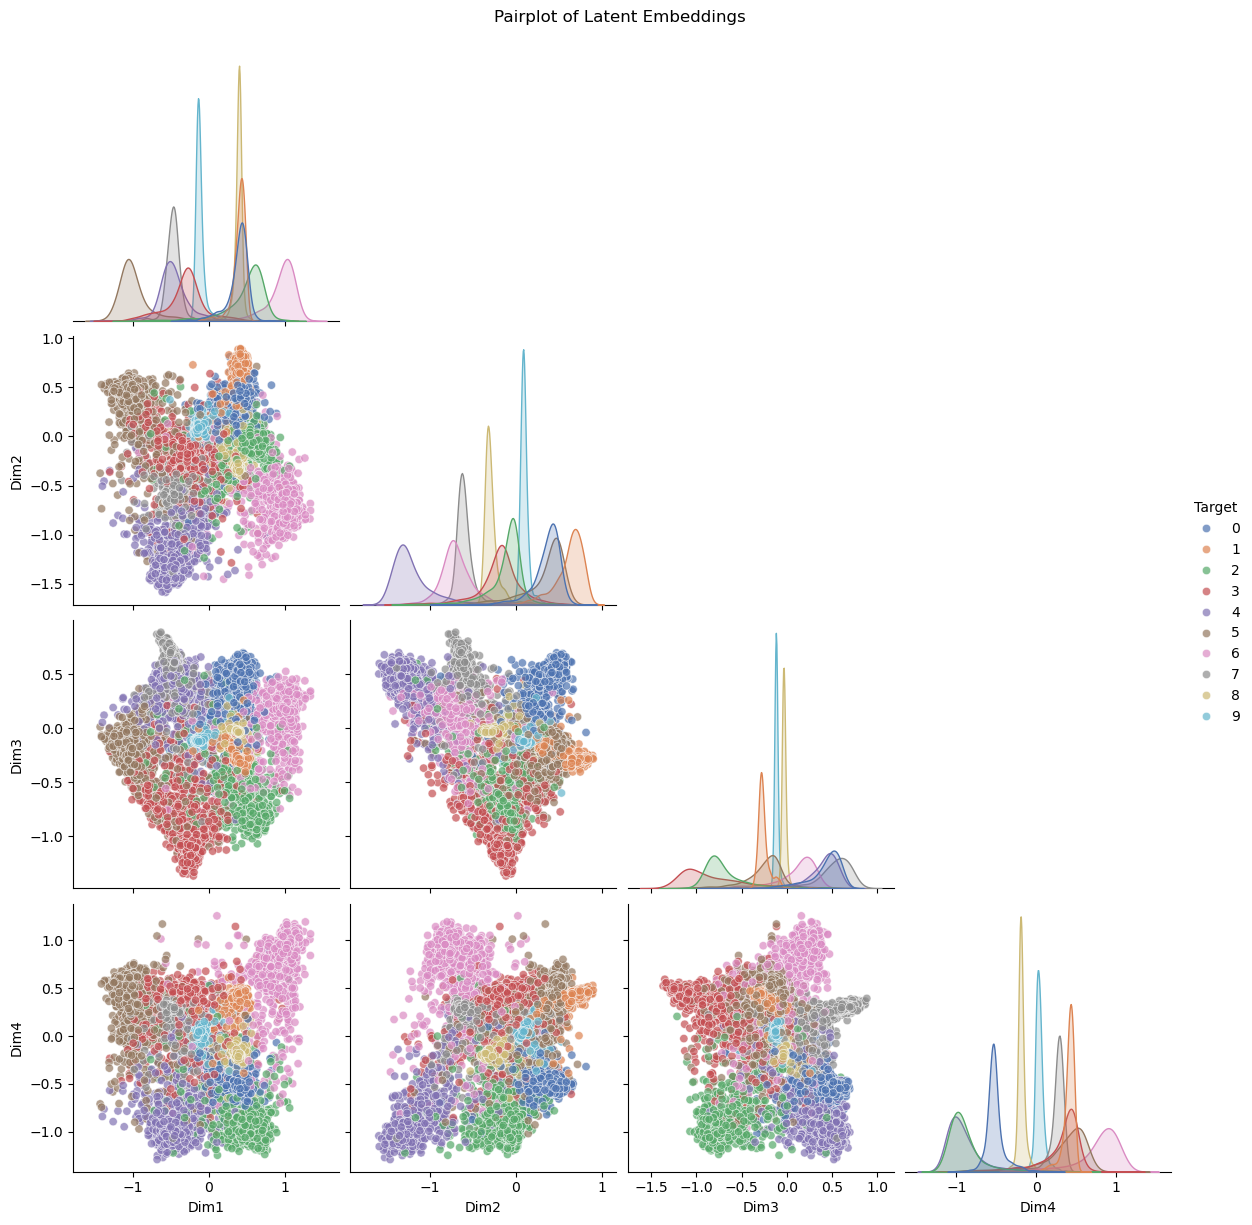

In [39]:
pairplot = sns.pairplot(df, hue='Target', palette='deep', diag_kind='kde', plot_kws={'alpha': 0.7}, corner=True, height=3, aspect=1)
pairplot.fig.suptitle('Pairplot of Latent Embeddings', y=1.02)
pairplot.savefig("images/pairplot_output.svg", format='svg')
plt.show()

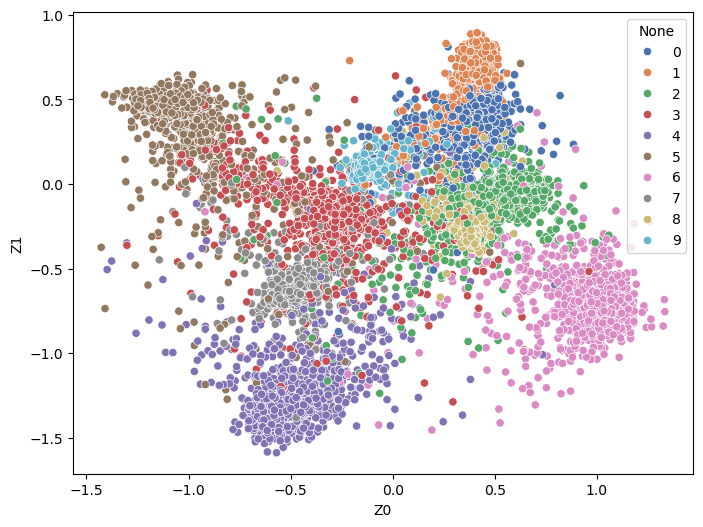

In [29]:
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(x=outputs[:, 0], y=outputs[:, 1], hue=targets, palette='deep')
ax.set_xlabel('Z0')
ax.set_ylabel('Z1')
plt.show()

In [41]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)
outputs_tsne = tsne.fit_transform(outputs)
df_tsne = pd.DataFrame(outputs_tsne, columns=['t-SNE1', 't-SNE2'])
df_tsne['Target'] = targets

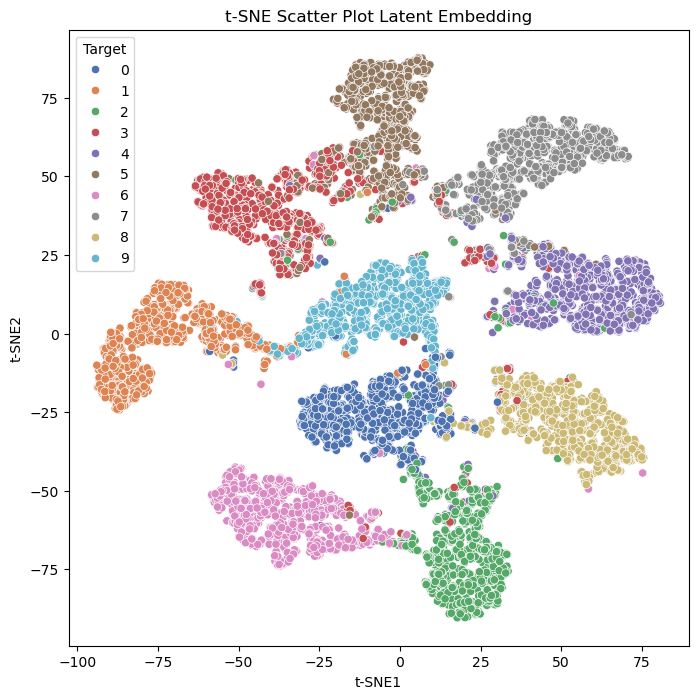

In [50]:
plt.figure(figsize=(8, 8))
ax = sns.scatterplot(data=df_tsne, x='t-SNE1', y='t-SNE2', hue='Target', palette='deep')
ax.set_title('t-SNE Scatter Plot Latent Embedding')

plt.savefig("images/tsne_latent.svg", format='svg')
plt.show()

In [54]:
import umap

umap_reducer = umap.UMAP(n_components=2)
outputs_umap = umap_reducer.fit_transform(outputs)

df_umap = pd.DataFrame(outputs_umap, columns=['UMAP1', 'UMAP2'])
df_umap['Target'] = targets

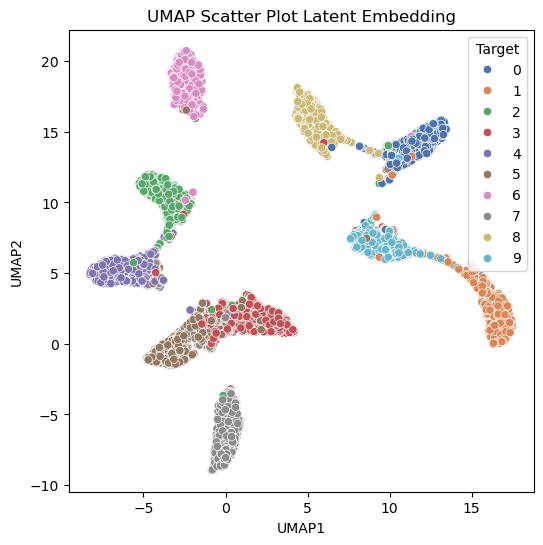

In [56]:
plt.figure(figsize=(6, 6))
ax = sns.scatterplot(data=df_umap, x='UMAP1', y='UMAP2', hue='Target', palette='deep')
ax.set_title('UMAP Scatter Plot Latent Embedding')

plt.savefig("images/umap_latent.svg", format='svg')
plt.show()